In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Outlier_Loan_dataset.csv')
df.head()

,User_ID,Loan_ID,City,Age,Job,Education,Marriage_Status,Account_Balance,Loan_Amount,Credit_Score,Debit_Transactions,Loan_Duration_Months,Application_Date,Current_Balance
0,U2169,L532233,Quetta,39.0,Clerk,Matric,Married,269967.77,29744.65,554.61,8955.54,45,2024-11-26,139275.96
1,U2807,L516508,Karachi,33.0,Driver,Matric,Married,246231.68,365315.52,606.98,14781.58,6,2024-08-18,61391.92
2,U4536,L471613,Peshawar,41.0,Manager,Bachelor,Divorced,202981.52,26227.40,629.32,15126.12,59,2024-01-27,115353.44
3,U9628,L354161,Lahore,50.0,Doctor,Matric,Married,167653.16,40761.15,744.38,18308.41,9,2022-09-19,136059.95
4,U8765,L650075,Karachi,32.0,Teacher,PhD,Married,234911.17,-6808.44,677.83,5431.99,35,2022-08-23,50588.27


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               1000 non-null   object 
 1   Loan_ID               1000 non-null   object 
 2   City                  1000 non-null   object 
 3   Age                   980 non-null    float64
 4   Job                   1000 non-null   object 
 5   Education             980 non-null    object 
 6   Marriage_Status       1000 non-null   object 
 7   Account_Balance       1000 non-null   float64
 8   Loan_Amount           980 non-null    float64
 9   Credit_Score          1000 non-null   float64
 10  Debit_Transactions    1000 non-null   float64
 11  Loan_Duration_Months  1000 non-null   int64  
 12  Application_Date      1000 non-null   object 
 13  Current_Balance       1000 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 109.5+ KB


In [ ]:
df.describe()

,Age,Account_Balance,Loan_Amount,Credit_Score,Debit_Transactions,Loan_Duration_Months,Current_Balance
count,980.000000,1.000000e+03,980.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,34.681633,2.445752e+05,65766.210602,658.063990,14655.084470,31.564000,100987.321210
std,9.772942,2.145093e+05,87270.271595,75.058019,6946.661359,15.342793,39492.372032
min,2.000000,5.298057e+04,-214960.080000,503.530000,-7236.930000,6.000000,-22578.270000
25%,28.000000,1.711243e+05,31202.785000,613.347500,10221.767500,18.000000,74024.610000
50%,35.000000,2.057074e+05,51769.330000,651.710000,14872.305000,31.000000,100390.475000
75%,41.000000,2.426467e+05,73401.505000,686.887500,19473.860000,44.000000,127794.932500
max,73.000000,1.769965e+06,868997.760000,1053.400000,36790.370000,59.000000,243978.670000


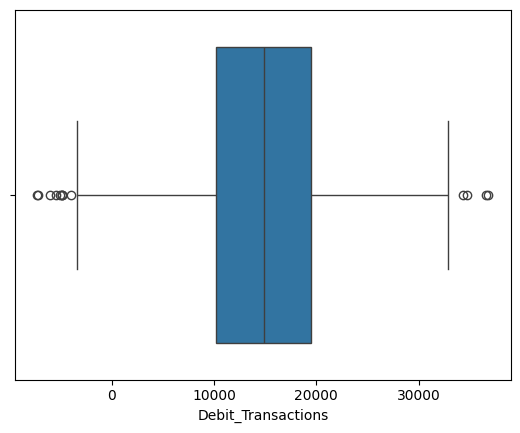

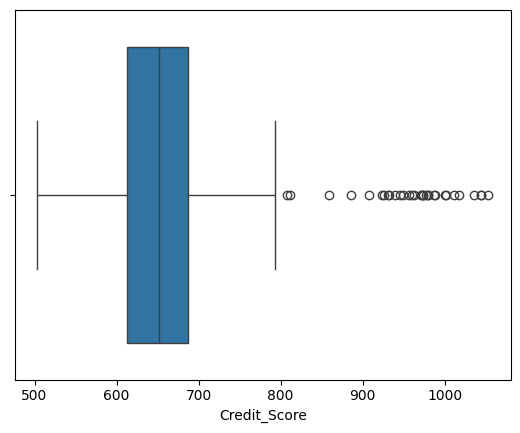

In [ ]:
sns.boxplot(x ="Debit_Transactions",data=df)
plt.show()
sns.boxplot(x ="Credit_Score",data=df)
plt.show()

/tmp/ipykernel_31243/4014102465.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Credit_Score'])


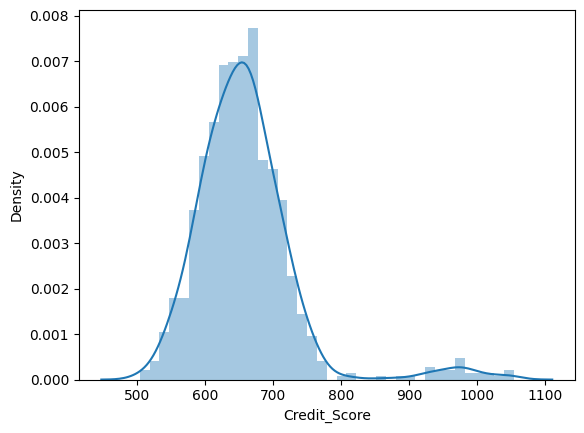

In [ ]:
sns.distplot(df['Credit_Score'])
plt.show()

In [ ]:
df.shape

(1000, 14)

In [ ]:
q1 = df['Credit_Score'].quantile(0.25)
q3 = df['Credit_Score'].quantile(0.75)
iqr = q3 - q1
min_range = q1 - 1.5 * iqr
max_range = q3 + 1.5 * iqr
min_range,max_range

(np.float64(503.03750000000014), np.float64(797.1975))

In [ ]:
new_data = df[(df['Credit_Score'] > min_range) & (df['Credit_Score'] < max_range)]
new_data.shape

(968, 14)

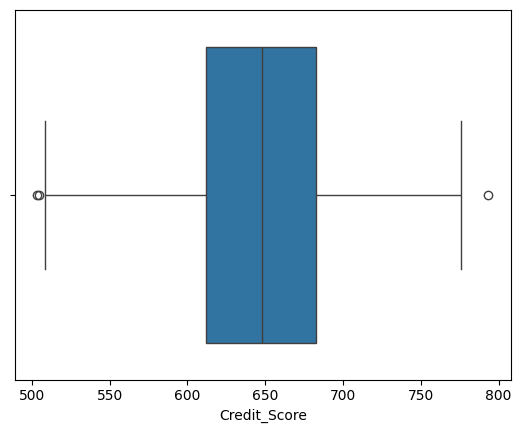

In [ ]:
sns.boxplot(x ="Credit_Score",data=new_data)
plt.show()

**z score**

In [ ]:
df.isnull().sum()

,0
User_ID,0
Loan_ID,0
City,0
Age,20
Job,0
Education,20
Marriage_Status,0
Account_Balance,0
Loan_Amount,20
Credit_Score,0


In [ ]:
min_r = df["Debit_Transactions"].mean() -(3*df["Debit_Transactions"].std())
max_r = df["Debit_Transactions"].mean() +(3*df["Debit_Transactions"].std())
new_dataset = df[df["Debit_Transactions"]<min_r]

In [ ]:
z_score = (df["Debit_Transactions"]-df["Debit_Transactions"].mean())/df["Debit_Transactions"].std()
df["z_score"] = z_score
df.shape

(1000, 15)

**function transformer**

/tmp/ipykernel_31243/2602659195.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Credit_Score'])


<function matplotlib.pyplot.show(close=None, block=None)>

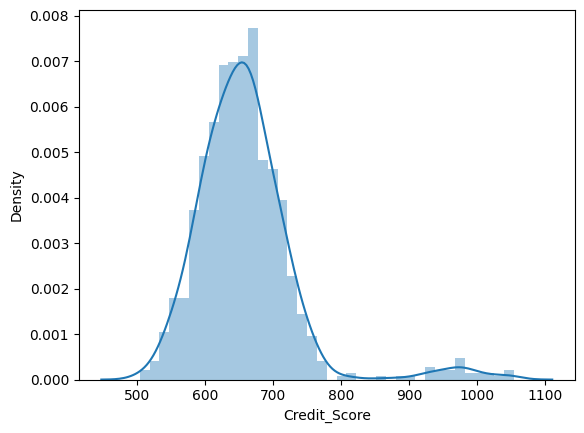

In [ ]:
sns.distplot(df['Credit_Score'])
plt.show

In [ ]:
from sklearn.preprocessing import FunctionTransformer
ft = FunctionTransformer(func=np.log1p)
df['Credit_Score_tf']=ft.fit_transform(df[['Credit_Score']])

/tmp/ipykernel_31243/1006275607.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Credit_Score'])
/tmp/ipykernel_31243/1006275607.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Credit_Score_tf'],color = "green")


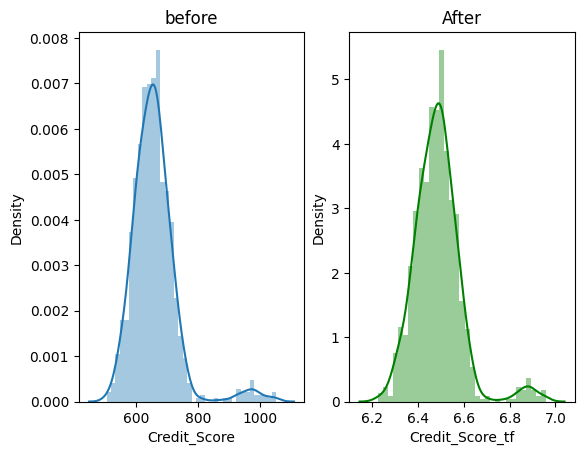

In [ ]:
plt.subplot(1,2,1)
sns.distplot(df['Credit_Score'])
plt.title("before")
plt.subplot(1,2,2)
sns.distplot(df['Credit_Score_tf'],color = "green")
plt.title("After")
plt.show()

/tmp/ipykernel_31243/3660119313.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Credit_Score'])
/tmp/ipykernel_31243/3660119313.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Credit_Score_tf1'],color = "red")


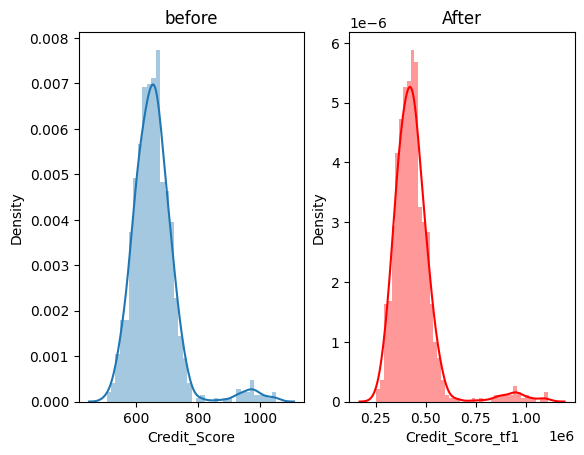

In [ ]:
from sklearn.preprocessing import FunctionTransformer
ft1 = FunctionTransformer(func=lambda x : x**2)
df['Credit_Score_tf1']=ft1.fit_transform(df[['Credit_Score']])
plt.subplot(1,2,1)
sns.distplot(df['Credit_Score'])
plt.title("before")
plt.subplot(1,2,2)
sns.distplot(df['Credit_Score_tf1'],color = "red")
plt.title("After")
plt.show()